# Task 3 – SQL, Python & Power BI Business Analysis

## Chinook Database Analysis

This project performs business analysis using SQL, Python, Pandas, and Power BI. The analysis focuses on sales, customers, products, genres, artists, countries, and business performance.

In [ ]:
import sqlite3
import pandas as pd

In [ ]:
conn = sqlite3.connect("/content/Chinook_Sqlite.sqlite")

print("Database connected successfully!")

Database connected successfully!


In [ ]:
import os

db_path = "/content/Chinook_Sqlite.sqlite"

print("File exists:", os.path.exists(db_path))
print("File size:", os.path.getsize(db_path), "bytes")

File exists: True
File size: 0 bytes


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

db_path = "/content/drive/MyDrive/task 3/Chinook_Sqlite.sqlite"

print("File exists:", os.path.exists(db_path))

if os.path.exists(db_path):
    print("File size:", os.path.getsize(db_path), "bytes")

File exists: True
File size: 1007616 bytes



## 1. Database Setup

The Chinook SQLite database was connected to Google Colab using Python and SQLite. The database contains information about customers, invoices, tracks, albums, artists, genres, and employees.

In [ ]:
import sqlite3

conn = sqlite3.connect(db_path)

print("Database connected successfully!")

Database connected successfully!


## 2. Database Tables

The database was inspected to identify the available tables and understand its structure before performing the business analysis.

In [ ]:
tables = pd.read_sql_query("""
SELECT name
FROM sqlite_master
WHERE type = 'table';
""", conn)

tables

,name
0,Album
1,Artist
2,Customer
3,Employee
4,Genre
5,Invoice
6,InvoiceLine
7,MediaType
8,Playlist
9,PlaylistTrack


## SQL Analysis

### Query 1 – Total Revenue

Calculate the total revenue generated from all invoices.

In [ ]:
query_1 = """
SELECT SUM(Total) AS Total_Revenue
FROM Invoice;
"""

total_revenue = pd.read_sql_query(query_1, conn)

total_revenue

,Total_Revenue
0,2328.6


### Query 2 – Top-Selling Tracks

Identify the tracks with the highest number of units sold.

In [ ]:
query_2 = """
SELECT
    t.Name AS Track_Name,
    SUM(il.Quantity) AS Units_Sold
FROM InvoiceLine il
JOIN Track t
    ON il.TrackId = t.TrackId
GROUP BY t.TrackId, t.Name
ORDER BY Units_Sold DESC
LIMIT 10;
"""

top_tracks = pd.read_sql_query(query_2, conn)

top_tracks

,Track_Name,Units_Sold
0,Balls to the Wall,2
1,Inject The Venom,2
2,Snowballed,2
3,Overdose,2
4,Deuces Are Wild,2
5,Not The Doctor,2
6,Por Causa De Você,2
7,Welcome Home (Sanitarium),2
8,Snowblind,2
9,Cornucopia,2


### Query 3 – Total Customers

Calculate the total number of customers in the Chinook database.

In [ ]:
query_3 = """
SELECT COUNT(*) AS Total_Customers
FROM Customer;
"""

total_customers = pd.read_sql_query(query_3, conn)

total_customers

,Total_Customers
0,59


### Query 4 – Total Orders

Calculate the total number of orders placed by customers.

In [ ]:
query_4 = """
SELECT COUNT(*) AS Total_Orders
FROM Invoice;
"""

total_orders = pd.read_sql_query(query_4, conn)

total_orders

,Total_Orders
0,412


### Query 5 – Average Order Value

Calculate the average amount spent per order.

In [ ]:
query_5 = """
SELECT ROUND(AVG(Total), 2) AS Average_Order_Value
FROM Invoice;
"""

average_order_value = pd.read_sql_query(query_5, conn)

average_order_value

,Average_Order_Value
0,5.65


### Query 6 – Average Spending per Customer

Calculate the average total spending per customer.

In [ ]:
query_6 = """
SELECT ROUND(AVG(Customer_Total), 2) AS Average_Spending_Per_Customer
FROM (
    SELECT CustomerId, SUM(Total) AS Customer_Total
    FROM Invoice
    GROUP BY CustomerId
);
"""

average_spending = pd.read_sql_query(query_6, conn)

average_spending

,Average_Spending_Per_Customer
0,39.47


### Query 7 – Top 10 Customers by Spending

Identify the top 10 customers based on their total spending.

In [ ]:
query_7 = """
SELECT
    c.CustomerId,
    c.FirstName || ' ' || c.LastName AS Customer_Name,
    ROUND(SUM(i.Total), 2) AS Total_Spending
FROM Customer c
JOIN Invoice i
    ON c.CustomerId = i.CustomerId
GROUP BY c.CustomerId, c.FirstName, c.LastName
ORDER BY Total_Spending DESC
LIMIT 10;
"""

top_customers = pd.read_sql_query(query_7, conn)

top_customers

,CustomerId,Customer_Name,Total_Spending
0,6,Helena Holý,49.62
1,26,Richard Cunningham,47.62
2,57,Luis Rojas,46.62
3,45,Ladislav Kovács,45.62
4,46,Hugh O'Reilly,45.62
5,24,Frank Ralston,43.62
6,28,Julia Barnett,43.62
7,37,Fynn Zimmermann,43.62
8,7,Astrid Gruber,42.62
9,25,Victor Stevens,42.62


### Query 8 – Revenue by Country

Calculate the total revenue generated by customers from each country.

In [ ]:
query_8 = """
SELECT
    c.Country,
    ROUND(SUM(i.Total), 2) AS Revenue
FROM Customer c
JOIN Invoice i
    ON c.CustomerId = i.CustomerId
GROUP BY c.Country
ORDER BY Revenue DESC;
"""

revenue_by_country = pd.read_sql_query(query_8, conn)

revenue_by_country

,Country,Revenue
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48
5,United Kingdom,112.86
6,Czech Republic,90.24
7,Portugal,77.24
8,India,75.26
9,Chile,46.62


### Query 9 – Customer Count by Country

Calculate the number of customers from each country.

In [ ]:
query_9 = """
SELECT
    Country,
    COUNT(*) AS Customer_Count
FROM Customer
GROUP BY Country
ORDER BY Customer_Count DESC;
"""

customer_count_country = pd.read_sql_query(query_9, conn)

customer_count_country

,Country,Customer_Count
0,USA,13
1,Canada,8
2,France,5
3,Brazil,5
4,Germany,4
5,United Kingdom,3
6,Portugal,2
7,India,2
8,Czech Republic,2
9,Sweden,1


### Query 10 – Top-Selling Genres

Identify the genres with the highest number of units sold.

In [ ]:
query_10 = """
SELECT
    g.Name AS Genre,
    SUM(il.Quantity) AS Units_Sold
FROM InvoiceLine il
JOIN Track t
    ON il.TrackId = t.TrackId
JOIN Genre g
    ON t.GenreId = g.GenreId
GROUP BY g.GenreId, g.Name
ORDER BY Units_Sold DESC;
"""

top_genres = pd.read_sql_query(query_10, conn)

top_genres

,Genre,Units_Sold
0,Rock,835
1,Latin,386
2,Metal,264
3,Alternative & Punk,244
4,Jazz,80
5,Blues,61
6,TV Shows,47
7,R&B/Soul,41
8,Classical,41
9,Reggae,30


### Query 11 – Top-Selling Artists

Identify the artists with the highest number of units sold.

In [ ]:
query_11 = """
SELECT
    ar.Name AS Artist,
    SUM(il.Quantity) AS Units_Sold
FROM InvoiceLine il
JOIN Track t
    ON il.TrackId = t.TrackId
JOIN Album al
    ON t.AlbumId = al.AlbumId
JOIN Artist ar
    ON al.ArtistId = ar.ArtistId
GROUP BY ar.ArtistId, ar.Name
ORDER BY Units_Sold DESC
LIMIT 10;
"""

top_artists = pd.read_sql_query(query_11, conn)

top_artists

,Artist,Units_Sold
0,Iron Maiden,140
1,U2,107
2,Metallica,91
3,Led Zeppelin,87
4,Os Paralamas Do Sucesso,45
5,Deep Purple,44
6,Faith No More,42
7,Lost,41
8,Eric Clapton,40
9,R.E.M.,39


### Query 12 – Revenue by Year

Calculate the total revenue generated in each year.

In [ ]:
query_12 = """
SELECT
    strftime('%Y', InvoiceDate) AS Year,
    ROUND(SUM(Total), 2) AS Revenue
FROM Invoice
GROUP BY Year
ORDER BY Year;
"""

revenue_by_year = pd.read_sql_query(query_12, conn)

revenue_by_year

,Year,Revenue
0,2021,449.46
1,2022,481.45
2,2023,469.58
3,2024,477.53
4,2025,450.58


### Query 13 – Revenue by Month

Calculate the total revenue generated in each month.

In [ ]:
query_13 = """
SELECT
    strftime('%m', InvoiceDate) AS Month_Number,
    ROUND(SUM(Total), 2) AS Revenue
FROM Invoice
GROUP BY Month_Number
ORDER BY Month_Number;
"""

revenue_by_month = pd.read_sql_query(query_13, conn)

revenue_by_month

,Month_Number,Revenue
0,01,201.12
1,02,187.20
2,03,195.10
3,04,198.14
4,05,193.10
5,06,201.10
6,07,190.10
7,08,198.10
8,09,196.20
9,10,193.10


### Query 14 – Yearly Sales Growth

Calculate the yearly revenue and year-over-year revenue growth.

In [ ]:
query_14 = """
WITH yearly_sales AS (
    SELECT
        CAST(strftime('%Y', InvoiceDate) AS INTEGER) AS Year,
        ROUND(SUM(Total), 2) AS Revenue
    FROM Invoice
    GROUP BY Year
)

SELECT
    Year,
    Revenue,
    ROUND(
        (Revenue - LAG(Revenue) OVER (ORDER BY Year))
        * 100.0
        / LAG(Revenue) OVER (ORDER BY Year),
        2
    ) AS Growth_Percentage
FROM yearly_sales
ORDER BY Year;
"""

sales_growth = pd.read_sql_query(query_14, conn)

sales_growth

,Year,Revenue,Growth_Percentage
0,2021,449.46,NaN
1,2022,481.45,7.12
2,2023,469.58,-2.47
3,2024,477.53,1.69
4,2025,450.58,-5.64


### Query 15 – Highest-Performing Country

Identify the country that generated the highest total revenue.

In [ ]:
query_15 = """
SELECT
    c.Country,
    ROUND(SUM(i.Total), 2) AS Revenue
FROM Customer c
JOIN Invoice i
    ON c.CustomerId = i.CustomerId
GROUP BY c.Country
ORDER BY Revenue DESC
LIMIT 1;
"""

highest_country = pd.read_sql_query(query_15, conn)

highest_country

,Country,Revenue
0,USA,523.06


### Query 16 – Highest-Performing Month

Identify the month with the highest total revenue.

In [ ]:
query_16 = """
SELECT
    strftime('%m', InvoiceDate) AS Month_Number,
    ROUND(SUM(Total), 2) AS Revenue
FROM Invoice
GROUP BY Month_Number
ORDER BY Revenue DESC
LIMIT 1;
"""

highest_month = pd.read_sql_query(query_16, conn)

highest_month

,Month_Number,Revenue
0,01,201.12


### Query 17 – Highest-Performing Artist

Identify the artist with the highest number of units sold.

In [ ]:
query_17 = """
SELECT
    ar.Name AS Artist,
    SUM(il.Quantity) AS Units_Sold
FROM InvoiceLine il
JOIN Track t
    ON il.TrackId = t.TrackId
JOIN Album al
    ON t.AlbumId = al.AlbumId
JOIN Artist ar
    ON al.ArtistId = ar.ArtistId
GROUP BY ar.ArtistId, ar.Name
ORDER BY Units_Sold DESC
LIMIT 1;
"""

highest_artist = pd.read_sql_query(query_17, conn)

highest_artist

,Artist,Units_Sold
0,Iron Maiden,140


### Query 18 – Customers with Highest Purchase Frequency

Identify customers who placed the highest number of orders.

In [ ]:
query_18 = """
SELECT
    c.CustomerId,
    c.FirstName || ' ' || c.LastName AS Customer_Name,
    COUNT(i.InvoiceId) AS Number_of_Orders
FROM Customer c
JOIN Invoice i
    ON c.CustomerId = i.CustomerId
GROUP BY c.CustomerId, c.FirstName, c.LastName
ORDER BY Number_of_Orders DESC
LIMIT 10;
"""

purchase_frequency = pd.read_sql_query(query_18, conn)

purchase_frequency

,CustomerId,Customer_Name,Number_of_Orders
0,1,Luís Gonçalves,7
1,2,Leonie Köhler,7
2,3,François Tremblay,7
3,4,Bjørn Hansen,7
4,5,František Wichterlová,7
5,6,Helena Holý,7
6,7,Astrid Gruber,7
7,8,Daan Peeters,7
8,9,Kara Nielsen,7
9,10,Eduardo Martins,7


### Query 19 – Revenue Contribution of Top Customers

Calculate the revenue generated by the top 10 customers and their percentage contribution to total revenue.

In [ ]:
query_19 = """
WITH customer_sales AS (
    SELECT
        c.CustomerId,
        c.FirstName || ' ' || c.LastName AS Customer_Name,
        SUM(i.Total) AS Total_Spending
    FROM Customer c
    JOIN Invoice i
        ON c.CustomerId = i.CustomerId
    GROUP BY c.CustomerId, c.FirstName, c.LastName
),
top_customers AS (
    SELECT *
    FROM customer_sales
    ORDER BY Total_Spending DESC
    LIMIT 10
)

SELECT
    ROUND(SUM(Total_Spending), 2) AS Top_10_Revenue,
    ROUND(
        SUM(Total_Spending) * 100.0 /
        (SELECT SUM(Total) FROM Invoice),
        2
    ) AS Revenue_Contribution_Percentage
FROM top_customers;
"""

revenue_contribution = pd.read_sql_query(query_19, conn)

revenue_contribution

,Top_10_Revenue,Revenue_Contribution_Percentage
0,451.2,19.38


### Query 20 – Customer Value Segmentation

Segment customers into High, Medium, and Low-value groups based on their total spending.

In [ ]:
query_20 = """
WITH customer_spending AS (
    SELECT
        c.CustomerId,
        c.FirstName || ' ' || c.LastName AS Customer_Name,
        ROUND(SUM(i.Total), 2) AS Total_Spending
    FROM Customer c
    JOIN Invoice i
        ON c.CustomerId = i.CustomerId
    GROUP BY c.CustomerId, c.FirstName, c.LastName
)

SELECT
    Customer_Name,
    Total_Spending,
    CASE
        WHEN Total_Spending >= 40 THEN 'High Value'
        WHEN Total_Spending >= 25 THEN 'Medium Value'
        ELSE 'Low Value'
    END AS Customer_Segment
FROM customer_spending
ORDER BY Total_Spending DESC;
"""

customer_segments = pd.read_sql_query(query_20, conn)

customer_segments

,Customer_Name,Total_Spending,Customer_Segment
0,Helena Holý,49.62,High Value
1,Richard Cunningham,47.62,High Value
2,Luis Rojas,46.62,High Value
3,Ladislav Kovács,45.62,High Value
4,Hugh O'Reilly,45.62,High Value
5,Frank Ralston,43.62,High Value
6,Julia Barnett,43.62,High Value
7,Fynn Zimmermann,43.62,High Value
8,Astrid Gruber,42.62,High Value
9,Victor Stevens,42.62,High Value


### Query 21 – High-Value Orders

Identify orders with a total value greater than $10 using the WHERE clause.

In [ ]:
query_21 = """
SELECT
    InvoiceId,
    CustomerId,
    ROUND(Total, 2) AS Order_Total
FROM Invoice
WHERE Total > 10
ORDER BY Total DESC;
"""

high_value_orders = pd.read_sql_query(query_21, conn)

high_value_orders.head(10)

,InvoiceId,CustomerId,Order_Total
0,404,6,25.86
1,299,26,23.86
2,96,45,21.86
3,194,46,21.86
4,89,7,18.86
5,201,25,18.86
6,88,57,17.91
7,306,5,16.86
8,313,43,16.86
9,103,24,15.86


### Query 22 – Countries with Revenue Above $100

Identify countries whose total revenue is greater than $100 using the HAVING clause.

In [ ]:
query_22 = """
SELECT
    c.Country,
    ROUND(SUM(i.Total), 2) AS Revenue
FROM Customer c
JOIN Invoice i
    ON c.CustomerId = i.CustomerId
GROUP BY c.Country
HAVING SUM(i.Total) > 100
ORDER BY Revenue DESC;
"""

countries_above_100 = pd.read_sql_query(query_22, conn)

countries_above_100

,Country,Revenue
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48
5,United Kingdom,112.86


## Python Analysis and Visualization

### Visualization 1 – Revenue by Country

This visualization shows the total revenue generated by customers from different countries.

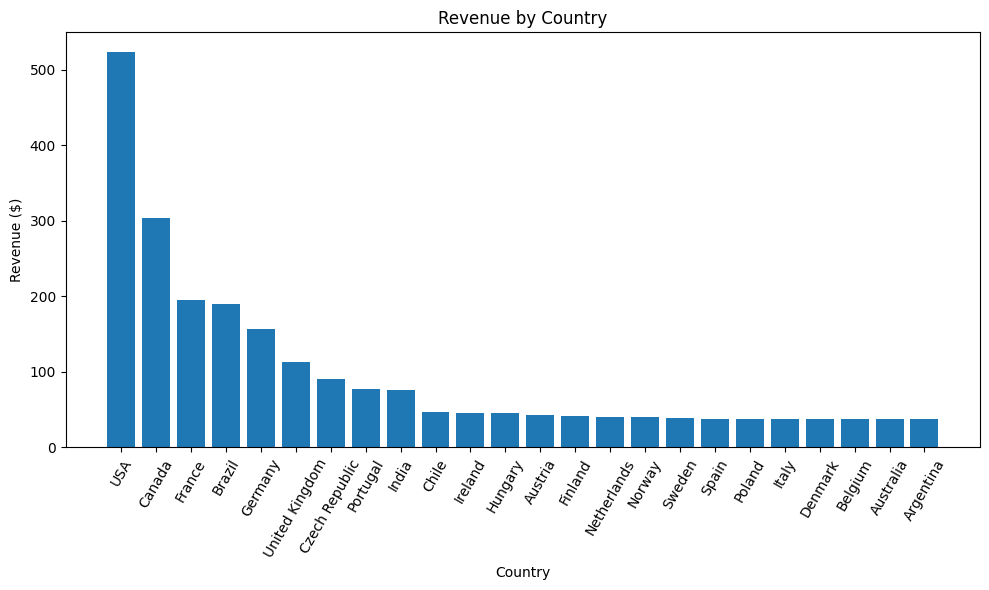

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    revenue_by_country["Country"],
    revenue_by_country["Revenue"]
)

plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=60)
plt.tight_layout()

plt.show()

### Visualization 2 – Top 10 Customers

This visualization shows the 10 customers who generated the highest total spending.

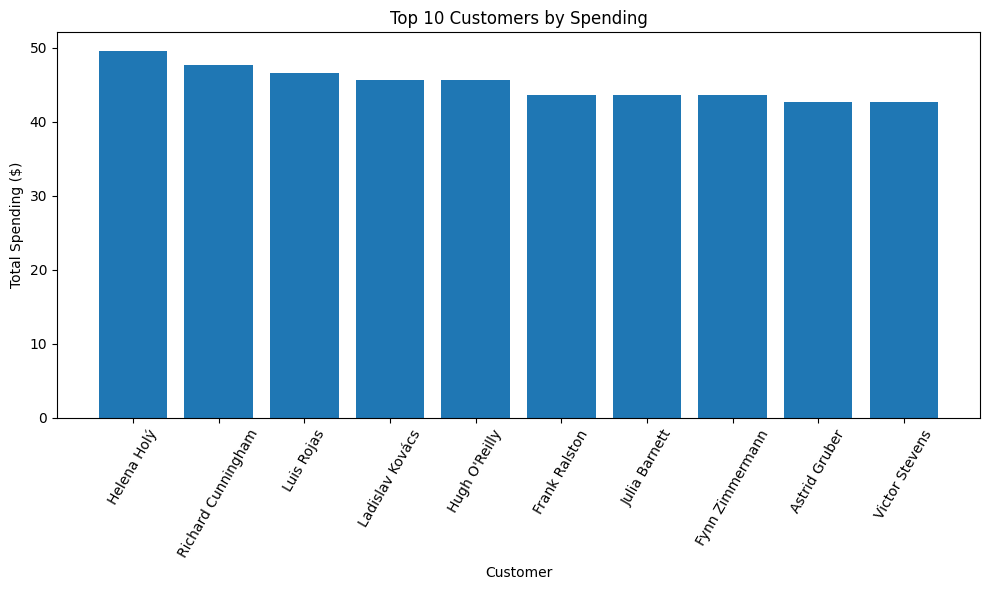

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    top_customers["Customer_Name"],
    top_customers["Total_Spending"]
)

plt.title("Top 10 Customers by Spending")
plt.xlabel("Customer")
plt.ylabel("Total Spending ($)")
plt.xticks(rotation=60)
plt.tight_layout()

plt.show()

### Visualization 3 – Revenue by Genre

This visualization shows the total revenue generated by each music genre.

In [ ]:
query_genre_revenue = """
SELECT
    g.Name AS Genre,
    ROUND(SUM(il.UnitPrice * il.Quantity), 2) AS Revenue
FROM InvoiceLine il
JOIN Track t
    ON il.TrackId = t.TrackId
JOIN Genre g
    ON t.GenreId = g.GenreId
GROUP BY g.GenreId, g.Name
ORDER BY Revenue DESC;
"""

revenue_by_genre = pd.read_sql_query(query_genre_revenue, conn)

revenue_by_genre

,Genre,Revenue
0,Rock,826.65
1,Latin,382.14
2,Metal,261.36
3,Alternative & Punk,241.56
4,TV Shows,93.53
5,Jazz,79.20
6,Blues,60.39
7,Drama,57.71
8,R&B/Soul,40.59
9,Classical,40.59


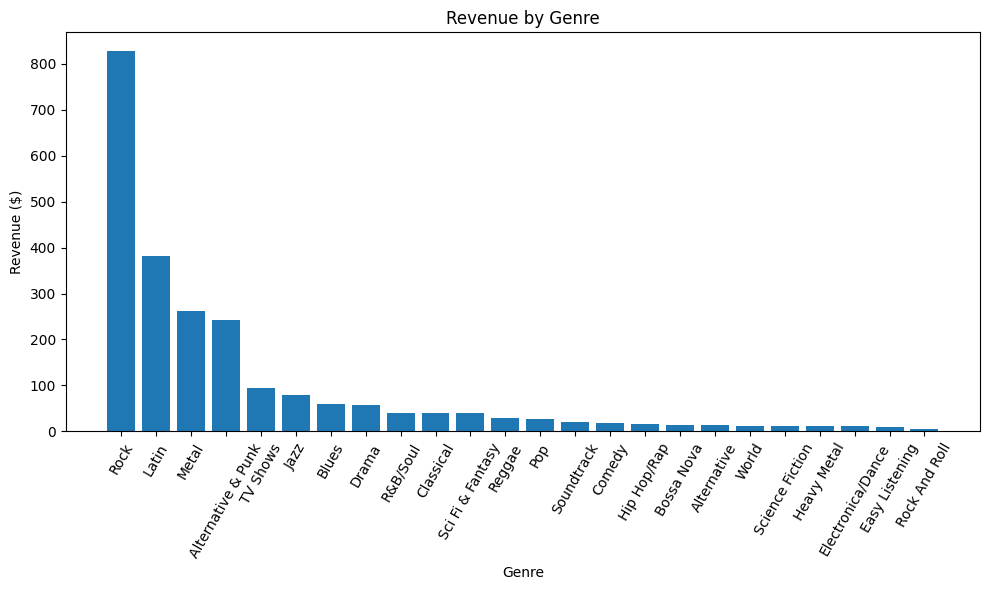

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    revenue_by_genre["Genre"],
    revenue_by_genre["Revenue"]
)

plt.title("Revenue by Genre")
plt.xlabel("Genre")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=60)
plt.tight_layout()

plt.show()

### Visualization 4 – Top Artists

This visualization shows the top 10 artists based on the number of units sold.

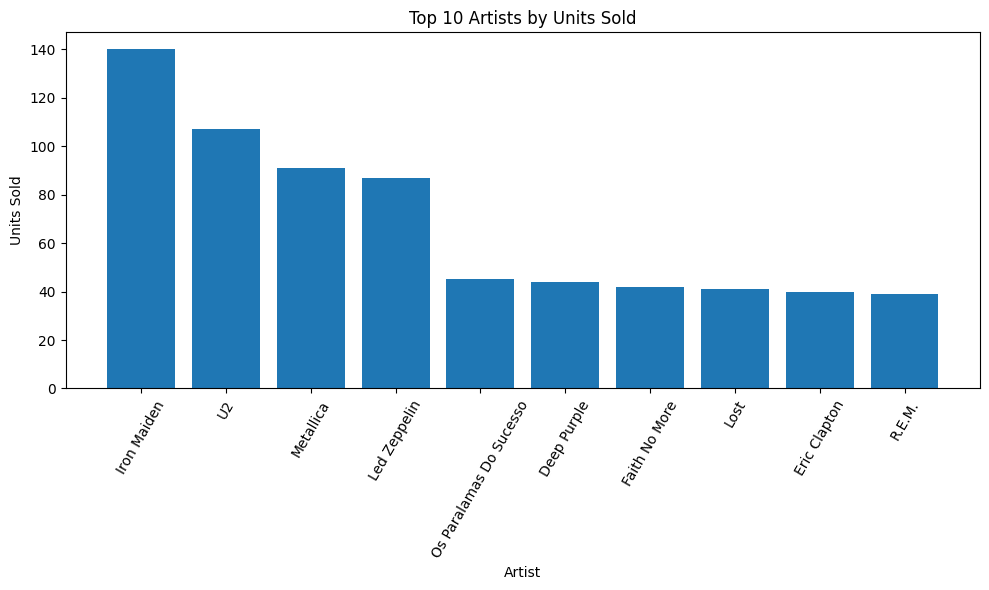

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    top_artists["Artist"],
    top_artists["Units_Sold"]
)

plt.title("Top 10 Artists by Units Sold")
plt.xlabel("Artist")
plt.ylabel("Units Sold")
plt.xticks(rotation=60)
plt.tight_layout()

plt.show()

### Visualization 5 – Monthly Sales Trend

This visualization shows how revenue changes across the months.

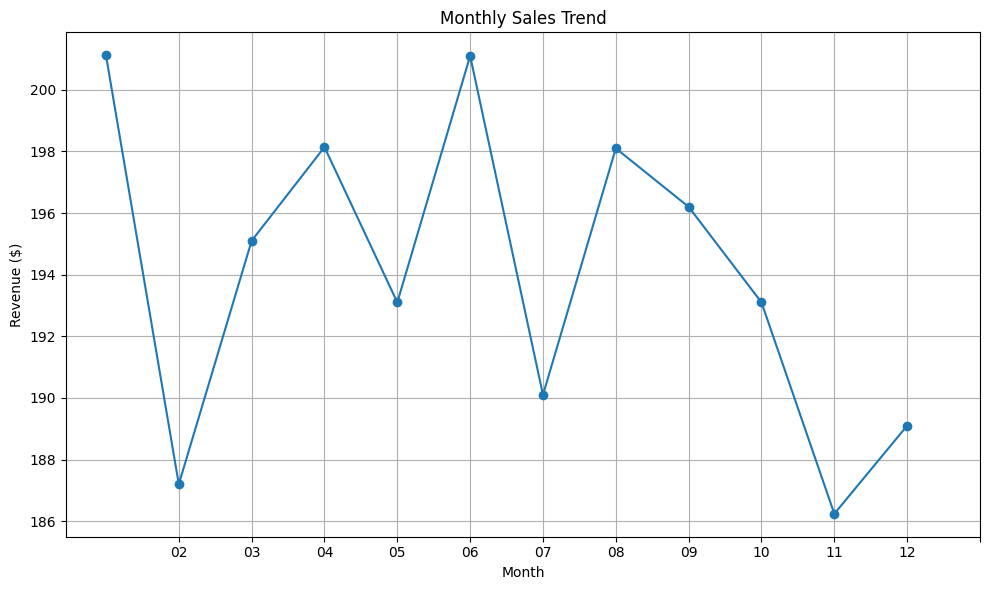

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    revenue_by_month["Month_Number"],
    revenue_by_month["Revenue"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(range(1, 13))
plt.grid(True)

plt.tight_layout()
plt.show()

### Visualization 6 – Customer Distribution by Country

This visualization shows the number of customers from each country.

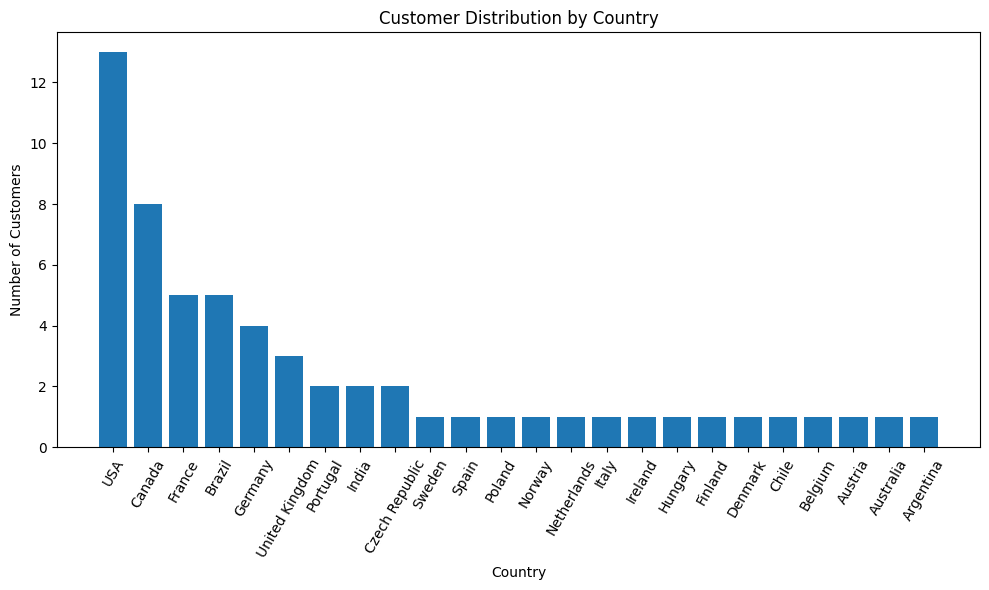

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    customer_count_country["Country"],
    customer_count_country["Customer_Count"]
)

plt.title("Customer Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

# Power BI Dashboard Preparation

The analyzed data was prepared for Power BI to create an interactive business dashboard. The dashboard will include key performance indicators, sales trends, customer analysis, genre performance, and country-level analysis.

In [ ]:
powerbi_query = """
SELECT
    i.InvoiceId,
    i.CustomerId,
    c.FirstName || ' ' || c.LastName AS Customer_Name,
    c.Country,
    i.InvoiceDate,
    strftime('%Y', i.InvoiceDate) AS Year,
    strftime('%m', i.InvoiceDate) AS Month,
    il.TrackId,
    t.Name AS Track_Name,
    g.Name AS Genre,
    al.Title AS Album,
    ar.Name AS Artist,
    il.Quantity,
    il.UnitPrice,
    ROUND(il.Quantity * il.UnitPrice, 2) AS Revenue
FROM Invoice i
JOIN Customer c
    ON i.CustomerId = c.CustomerId
JOIN InvoiceLine il
    ON i.InvoiceId = il.InvoiceId
JOIN Track t
    ON il.TrackId = t.TrackId
JOIN Genre g
    ON t.GenreId = g.GenreId
JOIN Album al
    ON t.AlbumId = al.AlbumId
JOIN Artist ar
    ON al.ArtistId = ar.ArtistId;
"""

powerbi_df = pd.read_sql_query(powerbi_query, conn)

powerbi_df.head()

,InvoiceId,CustomerId,Customer_Name,Country,InvoiceDate,Year,Month,TrackId,Track_Name,Genre,Album,Artist,Quantity,UnitPrice,Revenue
0,1,2,Leonie Köhler,Germany,2021-01-01 00:00:00,2021,01,2,Balls to the Wall,Rock,Balls to the Wall,Accept,1,0.99,0.99
1,1,2,Leonie Köhler,Germany,2021-01-01 00:00:00,2021,01,4,Restless and Wild,Rock,Restless and Wild,Accept,1,0.99,0.99
2,2,4,Bjørn Hansen,Norway,2021-01-02 00:00:00,2021,01,6,Put The Finger On You,Rock,For Those About To Rock We Salute You,AC/DC,1,0.99,0.99
3,2,4,Bjørn Hansen,Norway,2021-01-02 00:00:00,2021,01,8,Inject The Venom,Rock,For Those About To Rock We Salute You,AC/DC,1,0.99,0.99
4,2,4,Bjørn Hansen,Norway,2021-01-02 00:00:00,2021,01,10,Evil Walks,Rock,For Those About To Rock We Salute You,AC/DC,1,0.99,0.99


In [ ]:
print("Rows:", powerbi_df.shape[0])
print("Columns:", powerbi_df.shape[1])

Rows: 2240
Columns: 15


In [ ]:
powerbi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   InvoiceId      2240 non-null   int64  
 1   CustomerId     2240 non-null   int64  
 2   Customer_Name  2240 non-null   object 
 3   Country        2240 non-null   object 
 4   InvoiceDate    2240 non-null   object 
 5   Year           2240 non-null   object 
 6   Month          2240 non-null   object 
 7   TrackId        2240 non-null   int64  
 8   Track_Name     2240 non-null   object 
 9   Genre          2240 non-null   object 
 10  Album          2240 non-null   object 
 11  Artist         2240 non-null   object 
 12  Quantity       2240 non-null   int64  
 13  UnitPrice      2240 non-null   float64
 14  Revenue        2240 non-null   float64
dtypes: float64(2), int64(4), object(9)
memory usage: 262.6+ KB


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'Noor_Ul_Ain_Sagheer (2).pdf', 'Noor_Ul_Ain_Sagheer (1).pdf', 'week-1-titanic-data-prepartion', 'CNIC.pdf', 'Noor_Ul_Ain_Sagheer.pdf', 'task 3']


In [ ]:
os.makedirs("/content/drive/MyDrive/task 3", exist_ok=True)

powerbi_df.to_csv(
    "/content/drive/MyDrive/Task 3/powerbi_data.csv",
    index=False
)

print("Power BI dataset saved successfully!")

Power BI dataset saved successfully!


In [ ]:
os.makedirs("/content/drive/MyDrive/Task 3", exist_ok=True)

powerbi_df.to_csv(
    "/content/drive/MyDrive/Task 3/powerbi_data.csv",
    index=False
)

print("Power BI dataset saved successfully!")

Power BI dataset saved successfully!


## Power BI Dashboard Preparation

The analyzed data was combined into a single dataset and exported as a CSV file for Power BI. The dataset contains customer, country, date, genre, artist, track, quantity, and revenue information.